In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from iminuit import Minuit
import seaborn as sns
import matplotlib.patches as patches
from scipy import stats

In [23]:

def setup_plotting(ticksize=14, fontsize=16, figsize=(16, 9), dpi=150):
    """
    Global plotting setup:
    - Seaborn grey background
    - Custom reversed/de-saturated deep palette
    - Serif + STIX math fonts
    - Grid, linewidths, ticks, figure defaults
    """

    # --- Base style (grey background preserved) ---
    plt.style.use("seaborn-v0_8")
    sns.set()
    sns.set_context("paper", font_scale=1.4)
    sns.set_style("ticks")

    # --- Color palette ---
    #colors = sns.color_palette("deep", 10, desat=0.8)
    #colors = sns.color_palette("husl", 10)
    #colors = sns.color_palette("tab10", 10)
    colors = sns.color_palette("Set1", 10)
    #colors = colors[::-1]
    #colors.pop(2)
    sns.set_palette(colors)

    # --- Fonts ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"] + plt.rcParams["font.serif"],
        "mathtext.fontset": "stix",
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    return colors


def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
    
colors = setup_plotting(ticksize=14, fontsize=16, figsize=(16, 9), dpi=150)

In [24]:
x_axis = np.linspace(0,1,100)
prior = stats.beta(a=5, b=17)
prior_pdf = prior.pdf(x_axis)
likelihood = stats.binom.pmf(k=66, n=100, p=x_axis)

def proposal(x,mu, sig):
    return x + stats.norm.rvs(mu,sig)


In [32]:
def MH_alg(x_val, mu, sig, k =66, n=100 ):
    cand = -1
    while (cand < 0) or (cand > 1):
        cand = proposal(x_val, mu,sig)
    
    prob_cand = prior.pdf(cand) * stats.binom.pmf(k,n,p=cand)
    prob_prev = prior.pdf(x_val) * stats.binom.pmf(k,n,p=x_val)

    try:
        ratio = prob_cand/prob_prev
    except Exception as e:
        print(f"Error computing ratio: {e}")
        print(f"prob_cand: {prob_cand}, prob_prev: {prob_prev}")
        return x_val

    rand = np.random.uniform()

    if ratio > 1:
        return cand

    elif rand < ratio:
        
        return cand

    else:
        return x_val



In [34]:
Nsteps = 10000

# Pre-allocate array (much faster)
metropolis_sampling = np.zeros(Nsteps + 1)
metropolis_sampling[0] = 1.0

x_val = 1.0
for i in range(Nsteps):
    x_val = MH_alg(x_val, mu=0, sig=0.3)
    metropolis_sampling[i + 1] = x_val




/var/folders/t0/dsmc290j5355qf2rn298qwb40000gn/T/ipykernel_51650/871813880.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = prob_cand/prob_prev


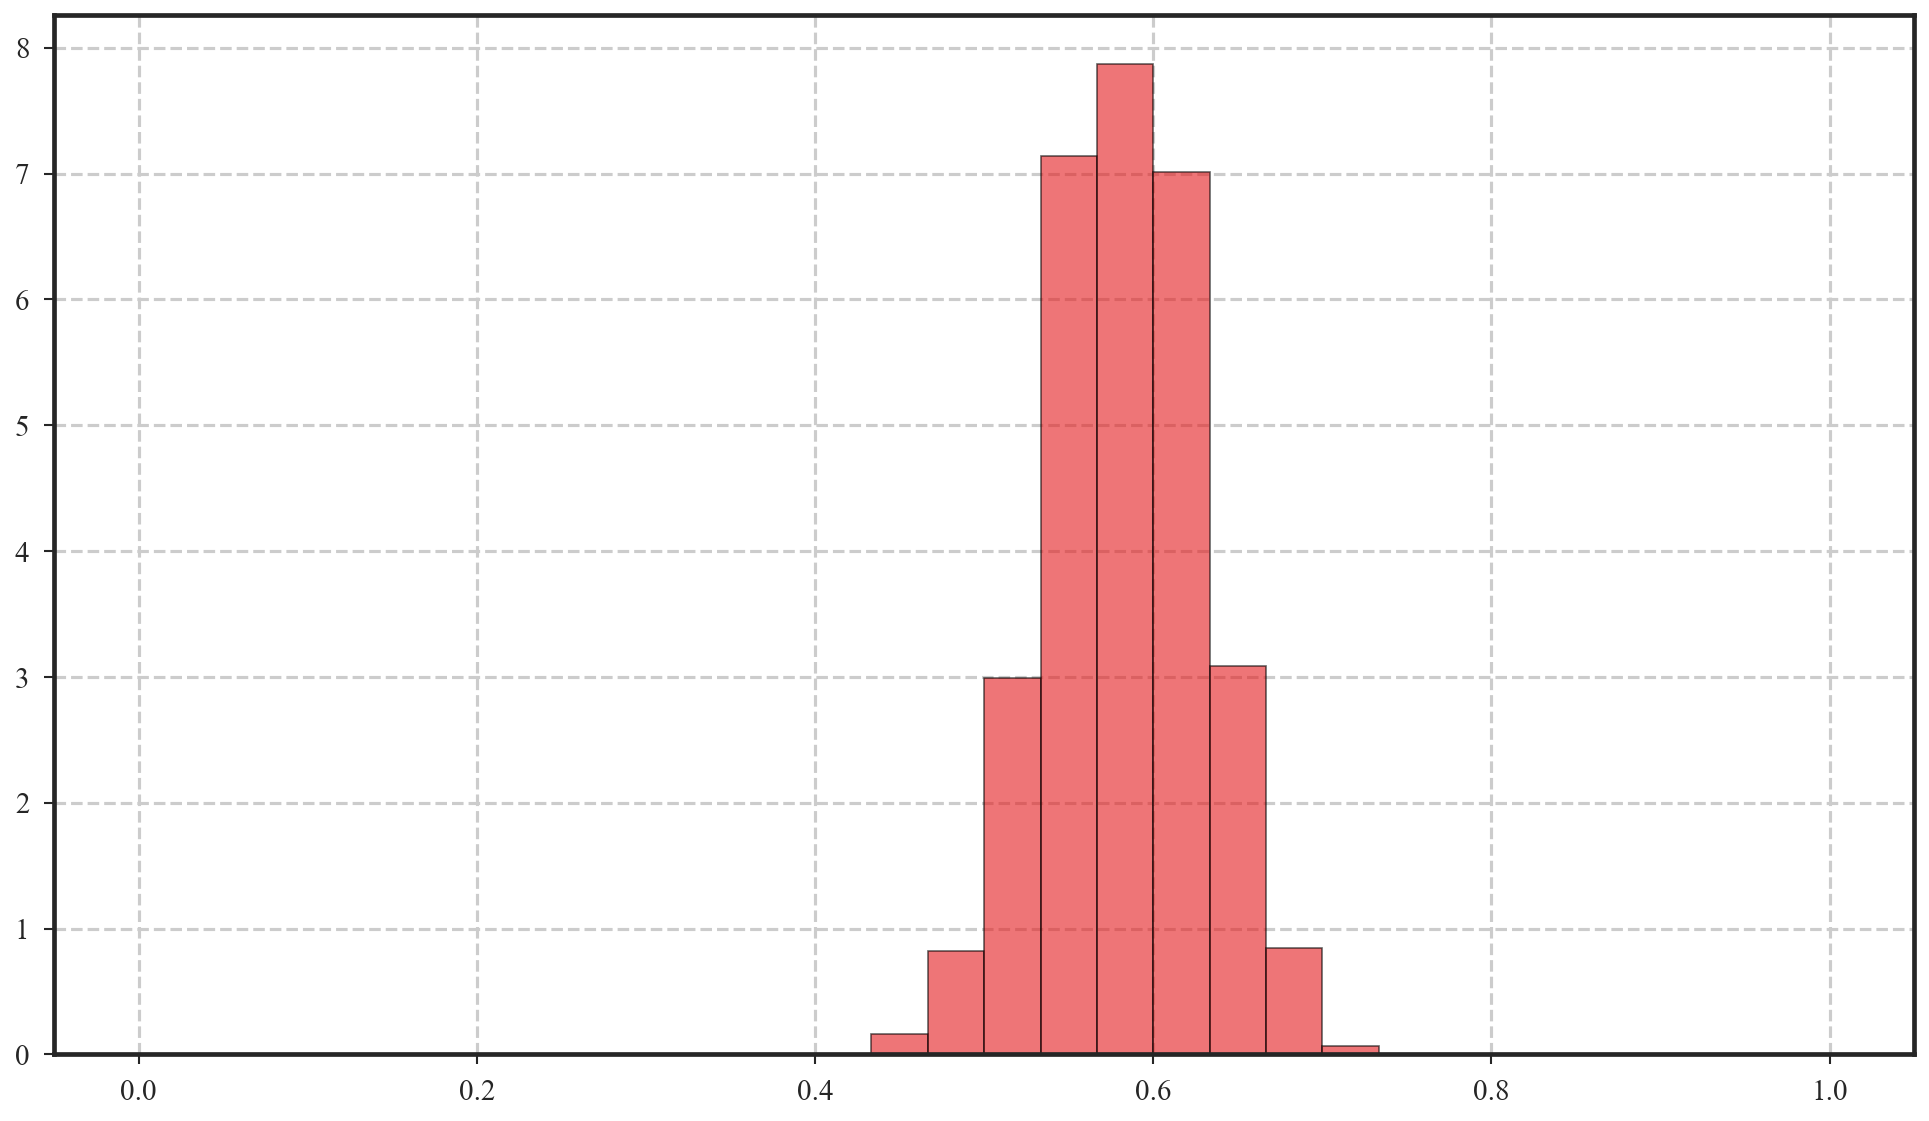

In [35]:
Nbins= 30

xrange = (0, 1)
counts, edges = np.histogram(metropolis_sampling, bins=Nbins, range=xrange, density=True)

plt.hist(metropolis_sampling, bins=Nbins, range=xrange, density=True, alpha=0.6, color=colors[0], edgecolor='black');